In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return np.exp(4*x) * np.sin(np.pi*y)

def T2(x, y):
    return np.pi*y + 4*np.pi*x*y

def E(x, y):
    return np.abs(f(x, y) - T2(x, y))

def taylor_grid_min_error(X, Y):
    X = np.asarray(X)
    Y = np.asarray(Y)
    tol=1e-12
    
    XX, YY = np.meshgrid(X, Y, indexing='ij')
    E = np.abs(f(XX, YY) - T2(XX, YY))
    min_error = np.min(E)

    indices = np.where(np.abs(E - min_error) < tol)
    min_points = np.array([[X[i], Y[j]] for i, j in zip(*indices)])

    return [np.array(min_points),min_error]

            RESULT

The minimizer (x*, y*):
 [[-5.    0.  ]
 [-4.99  0.  ]
 [-4.98  0.  ]
 ...
 [ 4.98  0.  ]
 [ 4.99  0.  ]
 [ 5.    0.  ]]

The minimum error E(x*, y*): 0.0


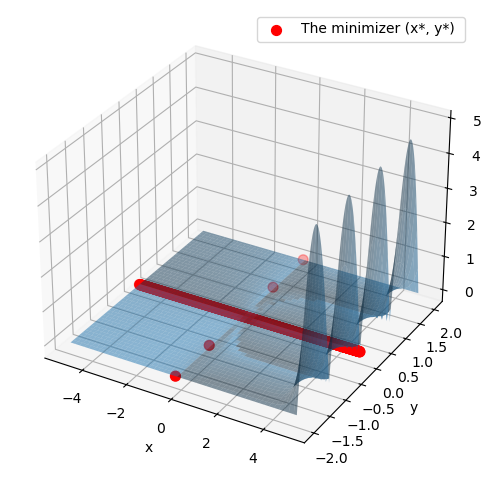

In [2]:
X = np.linspace(-5, 5, 1001)
Y = np.linspace(-2, 2, 1001)

result = taylor_grid_min_error(X, Y)
min_points = result[0]
min_error = result[1]

print("="*30)
print("            RESULT")
print("="*30, "\n")
print("The minimizer (x*, y*):\n", min_points)
print()
print("The minimum error E(x*, y*):", min_error)

XX, YY = np.meshgrid(X, Y, indexing='ij')
E = np.abs(f(XX, YY) - T2(XX, YY))

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(XX, YY, E, alpha=0.5)

ax.scatter(min_points[:,0], min_points[:,1], np.full(len(min_points), min_error),
           color='red', s=50, label='The minimizer (x*, y*) ')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('E(x,y)')
ax.legend()
plt.show()